<a href="https://colab.research.google.com/github/princeiiitk/Preventing-Customer-Churn-with-Feature-Transformation/blob/main/Preventing_Customer_Churn_with_Feature_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [593]:
!git clone 'https://github.com/princeiiitk/Preventing-Customer-Churn-with-Feature-Transformation'

fatal: destination path 'Preventing-Customer-Churn-with-Feature-Transformation' already exists and is not an empty directory.


In [594]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [595]:
df=pd.read_csv('/content/Preventing-Customer-Churn-with-Feature-Transformation/Telco-Customer-Churn.csv')

In [596]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [597]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**No Missing value in datase**t

In [598]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Step 2: Data Cleaning and Initial Preparation

In [599]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Problem with existing data set is `TotalCharge`s columns data type is `Object` it should be Float/int

In [600]:
print('shape before cleaning ',df.shape)

shape before cleaning  (7043, 21)


In [601]:

# Convert Totalcharges to numeric, coercing error to Nan
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print('shape after converting totalcharges to numeric',df.shape)

shape after converting totalcharges to numeric (7043, 21)


In [602]:
# find how many row have missing totalcharges
df['TotalCharges'].isnull().sum()

np.int64(11)

In [603]:
# impute the missing value with the median
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())
print('shape after converting totalcharges to numeric',df.shape)

shape after converting totalcharges to numeric (7043, 21)


In [604]:
# convert target variable 'churn' to binary
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [605]:
# Drop row with missing churn value
df.dropna(subset='Churn',inplace=True)

In [606]:
df.shape

(7043, 21)

In [607]:
# pd.set_option('display.max_columns',None)
# display(df.head(3))
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


In [608]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


# Step 3: Model 1 - Baseline Performance (Without Feature Engineering)

In [609]:
X_WFE=df.drop(columns=['customerID','Churn'])
y_WFE=df['Churn']

In [610]:
# identify Categorical and numerical features
numerical_features=X_WFE.select_dtypes(include=np.number)
categorical_features=X_WFE.select_dtypes(exclude=np.number)

In [611]:
categorical_features

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic)
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic)
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check


In [612]:
# creating the preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
preprocessing_wfe=ColumnTransformer([
    ('num',StandardScaler(),numerical_features.columns),
    ('cat',OneHotEncoder(drop='first'),categorical_features.columns)
])

In [613]:
X_WFE_train,X_WFE_test,y_WFE_train,y_WFE_test=train_test_split(X_WFE,y_WFE,test_size=0.2,random_state=42)

In [614]:
# creating the full pipeline with classifer
model_wfe=Pipeline(
    steps=[
        ('preprocessing',preprocessing_wfe),
        ('classifier',LogisticRegression(random_state=42,max_iter=1000))
    ]
)

In [615]:
# Model training
model_wfe.fit(X_WFE_train,y_WFE_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [616]:
y_pred_wfe=model_wfe.predict(X_WFE_test)
y_pred_wfe

array([1, 0, 0, ..., 0, 0, 0])

In [617]:
from sklearn.metrics import classification_report
print("--- Baseline Model Performance ---")
print(classification_report(y_WFE_test, y_pred_wfe))

--- Baseline Model Performance ---
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



# Step 4: The Core Task - Feature Engineering
Now, let's create a new, enriched DataFrame with more intelligent features.

In [618]:
df['tenure'].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [619]:
df_eng=df.copy()

In [620]:
# 1.Binning  'tenure'
bins=[0,12,24,36,48,60,72]
labels=['0-1 Year','1-2 Years','2-3 Years','3-4 Years','4-5 Years','5+ Years']
df_eng['tenure_group']=pd.cut(df_eng['tenure'],bins=bins,labels=labels,right=False)




In [621]:
# 2. Simplify categorical feature

# col=df_eng.columns
# for i in col:
#   for j in df_eng[i].unique():
#      if j in ['No internet service', 'No phone service']:
#             df_eng[i] = df_eng[i].replace(j, 'No')

df_eng.replace(['No internet service', 'No phone service'], 'No', inplace=True)

In [622]:
# 3 creating interaction/combination features
df_eng['num_add_service']=(df_eng[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']] =='Yes').sum(axis=1)

# 4. Create a feature for monthly charge to tenure ratio
df_eng['monthly_charge_ratio'] = df_eng['MonthlyCharges'] / (df_eng['tenure'] + 1) # +1 to avoid division by zero

In [623]:
df_eng.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_add_service,monthly_charge_ratio
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,1,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-3 Years,2,1.627143
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,2,17.950000
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3-4 Years,3,0.919565
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,0,23.566667
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,0-1 Year,3,11.072222
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0,1-2 Years,2,3.873913
7,6713-OKOMC,Female,0,No,No,10,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0,0-1 Year,1,2.704545
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,2-3 Years,4,3.613793
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,0,5+ Years,2,0.891270


In [624]:
df_eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   customerID            7043 non-null   object  
 1   gender                7043 non-null   object  
 2   SeniorCitizen         7043 non-null   int64   
 3   Partner               7043 non-null   object  
 4   Dependents            7043 non-null   object  
 5   tenure                7043 non-null   int64   
 6   PhoneService          7043 non-null   object  
 7   MultipleLines         7043 non-null   object  
 8   InternetService       7043 non-null   object  
 9   OnlineSecurity        7043 non-null   object  
 10  OnlineBackup          7043 non-null   object  
 11  DeviceProtection      7043 non-null   object  
 12  TechSupport           7043 non-null   object  
 13  StreamingTV           7043 non-null   object  
 14  StreamingMovies       7043 non-null   object  
 15  Cont

**Step 5: Model 2 - Performance with Engineered Features**

In [625]:
# Drop original tenure as we have a binned version now
df_eng.drop(columns=['tenure','customerID'],inplace=True)

# define feature (X) and target (y) for the engineer dataset
X_eng = df_eng.drop('Churn', axis=1)
y_eng = df_eng['Churn']

# Identify new feature type
numerical_features_eng=X_eng.select_dtypes(include=np.number)
categorical_features_eng=X_eng.select_dtypes(include=['object','category'])

# creating preprocessing pipeline
preprocessing_eng = ColumnTransformer([
    ('num',StandardScaler(),numerical_features_eng.columns),
    ('cat',OneHotEncoder(drop='first'),categorical_features_eng.columns)
])

# spliting
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng)

In [626]:
# Make pipeline
model2=Pipeline(
    steps=[(
        'preprocessing',preprocessing_eng),
           ('classifier',LogisticRegression(random_state=42,max_iter=1000))]
)

In [627]:
X_train_eng

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group,num_add_service,monthly_charge_ratio
3738,Male,0,No,No,No,No,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,2-3 Years,3,1.366667
3151,Male,0,Yes,Yes,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,1-2 Years,1,4.693750
4860,Male,0,Yes,Yes,No,No,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,1-2 Years,3,2.896429
3867,Female,0,Yes,No,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,2-3 Years,4,2.722222
3810,Male,0,Yes,Yes,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,0-1 Year,0,22.275000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,Female,0,Yes,No,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109.25,7707.70,5+ Years,5,1.517361
6227,Male,0,No,No,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),46.05,80.35,0-1 Year,0,15.350000
4673,Female,1,No,No,Yes,Yes,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,102.80,2660.20,2-3 Years,4,3.953846
2710,Female,0,Yes,No,Yes,No,No,No,No,No,No,No,No,One year,No,Credit card (automatic),20.40,482.80,2-3 Years,0,0.816000


In [628]:
# Train and evaluate the enhanced model
model2.fit(X_train_eng, y_train_eng)
y_pred_eng =model2.predict(X_test_eng)

print("--- Enhanced Model Performance (with Feature Engineering) ---")
print(classification_report(y_test_eng, y_pred_eng))

--- Enhanced Model Performance (with Feature Engineering) ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [639]:
# To get feature importance, let's quickly train a RandomForest model with the engineered data
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessing_eng),
                               ('classifier', RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train_eng, y_train_eng)
# Extract feature names after one-hot encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

feature_importance_df

,Feature,Importance
4,num__monthly_charge_ratio,0.221482
2,num__TotalCharges,0.160325
1,num__MonthlyCharges,0.144410
10,cat__InternetService_Fiber optic,0.039871
3,num__num_add_service,0.036635
22,cat__PaymentMethod_Electronic check,0.034327
19,cat__Contract_Two year,0.029947
5,cat__gender_Male,0.025967
20,cat__PaperlessBilling_Yes,0.025961
12,cat__OnlineSecurity_Yes,0.022426


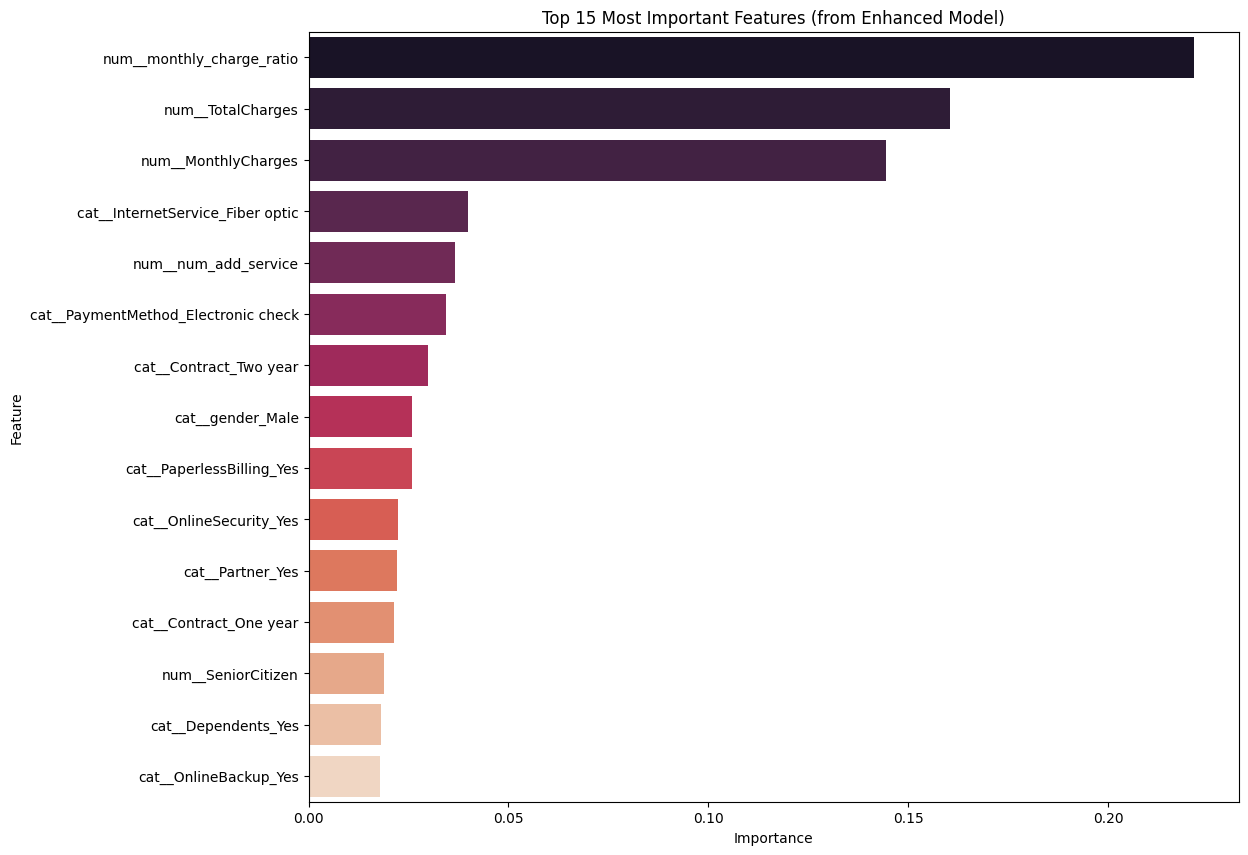

In [640]:
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='rocket', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features (from Enhanced Model)')
plt.show()

In [668]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier to use as the base estimator for feature selection
rf_selector = RandomForestClassifier(random_state=42)

# Instantiate SelectFromModel
# Using 'median' as the threshold means features with importance greater than the median importance will be selected.
selector = SelectFromModel(estimator=rf_selector, threshold='median', prefit=False)

from sklearn.linear_model import LogisticRegression

model2=LogisticRegression()

pipeLine=Pipeline([
    ('preprocessing',preprocessing_eng),
    ('selector',selector),
    ('classifier',model2)]

)


In [670]:
pipeLine.fit(X_train_eng,y_train_eng)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'num_add_service',
       'monthly_charge_ratio'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'tenure_group'],
      dtype='object'))])),
                ('selector',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 threshold='median')),
                ('classifier', LogisticRegression())])

In [673]:
y_pred1 = pipeLine.predict(X_test_eng)

In [674]:
accuracy = accuracy_score(y_test_eng, y_pred1)

print("Accuracy:", accuracy)

Accuracy: 0.7998580553584103
